In [3]:
from ioMicro import read_im
import matplotlib.pyplot as plt
import numpy as np
import glob
import zarr
import os

##### Load raw image data

In [9]:
data_folder = r'D:\Zane\10_12_2023__CRE-20_RNASEQ'

# map all the hybes
hybes =  glob.glob(data_folder+os.sep+'H*')
# map all the fovs
fovs = [os.path.basename(fl) for fl in glob.glob(hybes[0]+os.sep+'*.zarr')]
def get_Hi(fld): 
    try: return int(os.path.basename(fld)[1:]) 
    except: return -1
    
hybes = np.array(hybes)[np.argsort([get_Hi(hybe) for hybe in hybes ])]
fovs.sort()

zarr_files = r'D:\Zane\10_12_2023__CRE-20_RNASEQ\H9\Conv_zscan__*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))

im_path = r'D:\Zane\10_12_2023__CRE-20_RNASEQ\*'
imgs = [read_im(im_path) for im_path in files]

In [11]:
imgs[9]

dask.array<swapaxes, shape=(4, 50, 2800, 2800), dtype=uint16, chunksize=(4, 1, 2800, 2800), chunktype=numpy.ndarray>

##### Load specific enhancer spots in a given FOV

In [16]:
fov['Xh'][:,2]

array([1448.01186603, 1457.94640835, 1404.99682585, ..., 1051.92779142,
       1008.97429514, 1003.87325462])

In [4]:
fov = np.load(r'C:\Users\zgibbs\cellpose\Conv_zscan__009--H1_fits_icol0.npz',
                 allow_pickle=True)

mol_names = list(fov['mol_names'])
elem = 'CRE001'

if elem in mol_names:
    counter = 0
    elem_pos = []
    for i in mol_names:
        if i == elem:
            elem_pos.append(counter)
        counter = counter + 1
    num_spots = len(elem_pos)
    print(str(num_spots) + ' spots found')

spots = [fov['XH'][i] for i in elem_pos]

KeyError: 'mol_names is not a file in the archive'

##### Plot enhancer spots on top of raw image

In [22]:
spots

NpzFile 'C:\\Users\\zgibbs\\cellpose\\Conv_zscan__009--H1_fits_icol0.npz' with keys: Xh

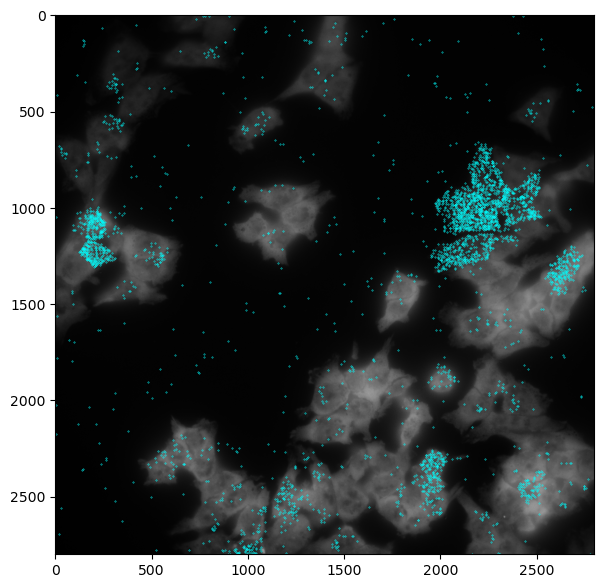

In [45]:
fig, ax = plt.subplots(figsize=(7,7))

spots = np.load(r'C:\Users\zgibbs\cellpose\Conv_zscan__009--H7_fits_icol1.npz', allow_pickle=True)

h = spots['Xh'][:,7]
keep = np.where((h>400) & (h<1800))
spots_ = spots['Xh'][keep]

x = spots_[:,2]
y = spots_[:,1]

# ax.imshow(imgs[34][4,10,:,:], cmap='gray', vmax=5000)
ax.imshow(imgs[9][2,10,:,:], cmap='gray', vmax=15000)

ax.scatter(x, y, s=0.1, c='cyan')

# plt.savefig(r'C:\Users\zgibbs\cellpose\HCT116_20CRE_rep1\figures\CRE020_fov009.pdf')
plt.show()

In [265]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
torch.cuda.is_available()

True

In [266]:
torch.cuda.get_device_name(0)

'NVIDIA RTX A6000'

##### Segment FOV to provide cell masks

In [299]:
from cellpose import models, io
from tqdm import tqdm
import torch

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'
# pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320'

model = models.CellposeModel(gpu=True, model_type='cyto2',
                             device=torch.device(0))

masks, flows, styles = model.eval(imgs[34][3,10,:,:], channels=[0,0], diameter=250)

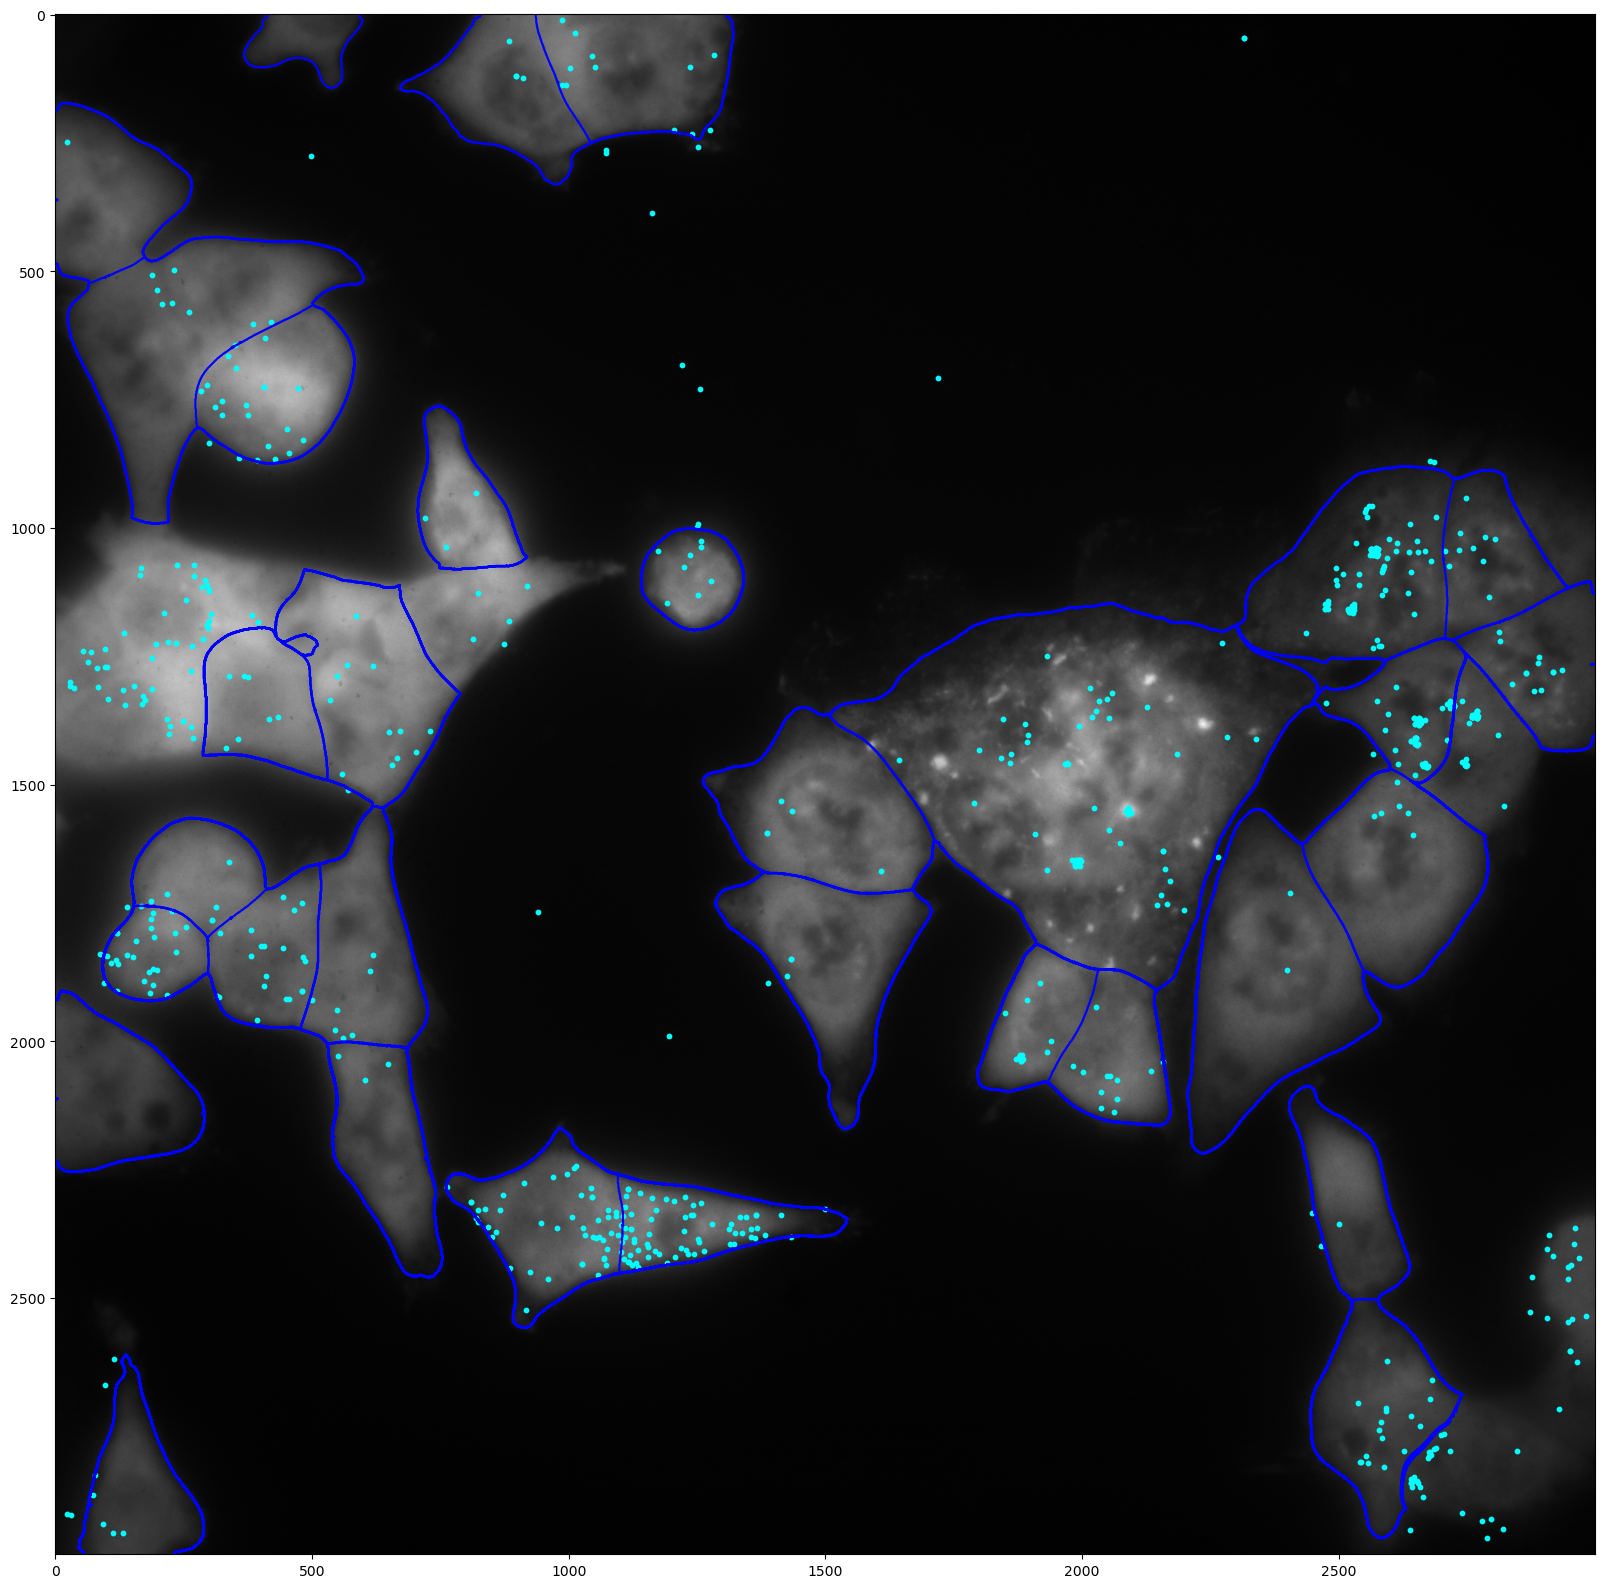

In [321]:
fig, ax = plt.subplots(figsize=(20,20))

ax.imshow(imgs[34][3,10,:,:], cmap='gray')
ax.contour(masks, [0.5+x for x in np.unique(masks)], colors='b')
x = [spots[i][3][2] for i in range(num_spots)]
y = [spots[i][3][1] for i in range(num_spots)]
ax.scatter(x, y, s=10, c='cyan')

# plt.savefig(r'C:\Users\zgibbs\cellpose\HCT116_300CRE\figures\CRE280_fov034', dpi=600)
plt.show()